In [247]:
#Importing required libaries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Importing modules from sklearn library
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score

#Importing harmless warnings
import warnings
warnings.filterwarnings('ignore')

In [248]:
#Data import
data = sns.load_dataset('iris')

In [249]:
#Data Sample
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [250]:
#Data dimensions
data.shape

(150, 5)

In [251]:
# Missing value and dtype check
pd.DataFrame({'Missing Values' : round(data.isnull().mean()*100, 2), 'Dtypes' : data.dtypes})

,Missing Values,Dtypes
sepal_length,0.0,float64
sepal_width,0.0,float64
petal_length,0.0,float64
petal_width,0.0,float64
species,0.0,object


In [252]:
# Duplicate checks in row
data[data.duplicated(keep=False)] # Get all rows that appear more than once

,sepal_length,sepal_width,petal_length,petal_width,species
101,5.8,2.7,5.1,1.9,virginica
142,5.8,2.7,5.1,1.9,virginica


In [253]:
#Checking if duplicates are removed
if len(data[data.duplicated(keep=False)]) == 0:    # Get all rows that appear more than once
    print('Data duplicates in row is zero')
else:
    print('Data duplicates in row still exists')   

Data duplicates in row still exists


In [254]:
#Checking duplicates in columns
has_duplicates = data.shape[1] != data.T.drop_duplicates().T.shape[1]
if has_duplicates == True:
    print('Column duplicates still exist')
elif has_duplicates == False:
    print('Column duplicates does not exist') 

Column duplicates does not exist


In [255]:
#Analysing target column
data['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

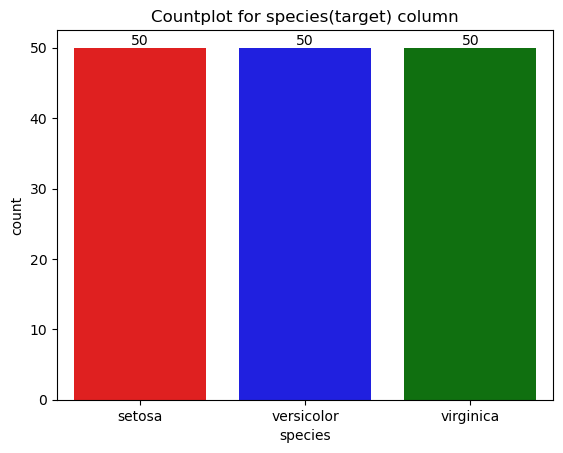

In [256]:
#Plotting the target column
ax = sns.countplot(data = data, x = data['species'],  palette=['red', 'blue', 'green'])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
ax.bar_label(ax.containers[2])
ax.set_title('Countplot for species(target) column')
plt.show()

In [257]:
#label encoding the target variable
encoder = LabelEncoder()
data['species'] = encoder.fit_transform(data['species'])

#Data after encoding
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [258]:
#Dependency split
x = data.drop(['species'], axis = 1)
y = data['species']

#Train test split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42, stratify = y) 

#Dimensions after split
print('Dimensions of train columns:', x_train.shape, y_train.shape)
print('Dimensions of test columns:', x_test.shape, y_test.shape)

Dimensions of train columns: (120, 4) (120,)
Dimensions of test columns: (30, 4) (30,)


In [259]:
y_train.value_counts()

species
0    40
2    40
1    40
Name: count, dtype: int64

In [260]:
# Train scaling
scale = StandardScaler()
x_train_scaled = scale.fit_transform(x_train)

# Test scaling
x_test_scaled = scale.transform(x_test)

In [261]:
# KNN Algo

error = []

for k in range(1,40):
    knn_model = KNeighborsClassifier(n_neighbors = k, weights = 'distance', n_jobs = -1)
    knn_model.fit(x_train_scaled, y_train)
    y_pred = knn_model.predict(x_test_scaled)
    error.append(np.mean(y_pred != y_test.values))

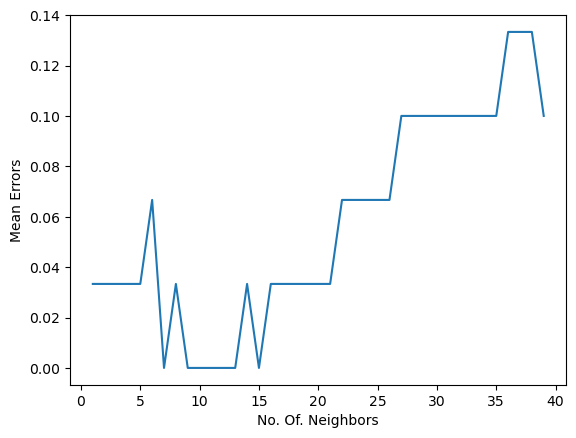

In [262]:
# Neighbors v/s Error plot
plt.plot(range(1, 40), error)
plt.xlabel('No. Of. Neighbors')
plt.ylabel('Mean Errors')
plt.show()

In [263]:
#Using cross validation to find the optimum number of neighbors
k_value = range(1, 22)
cv_score = []

for k in k_value:
    knn_cv = KNeighborsClassifier(n_neighbors=k, weights='distance', n_jobs=-1)
    scores = cross_val_score(knn_cv, x_train_scaled, y_train, scoring='accuracy', n_jobs=-1)
    cv_score.append(scores.mean())

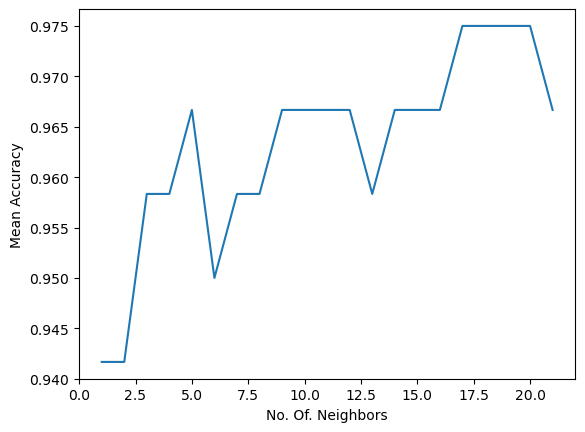

In [264]:
# accuracy vs neighbors
plt.plot(range(1, 22), cv_score)
plt.xlabel('No. Of. Neighbors')
plt.ylabel('Mean Accuracy')
plt.show()

In [265]:
#Final model with the optimum number of neighbors
model = KNeighborsClassifier(n_neighbors=10, weights='distance', n_jobs=-1)
model.fit(x_train_scaled, y_train)
print('Training Score:', round(model.score(x_train_scaled, y_train)*100, 2), '%')

Training Score: 100.0 %


In [266]:
#Predictions
y_pred = model.predict(x_test_scaled)

#Metrics
print('Testing Score:', round(accuracy_score(y_test, y_pred)*100, 2), '%')

Testing Score: 100.0 %


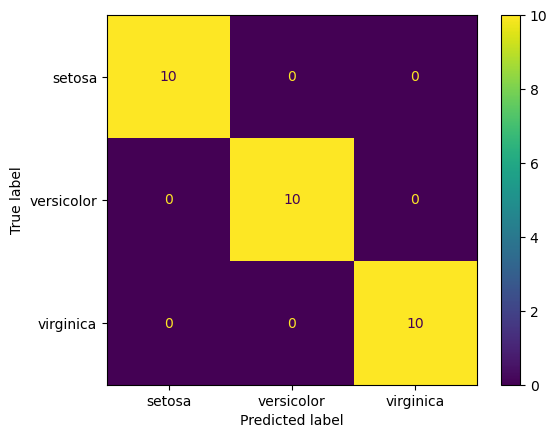

In [267]:
#Confusion Matrix
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=list(encoder.inverse_transform([0, 1, 2])))